# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('/content/sample_data/train.csv')
current = pd.read_csv('/content/sample_data/current.csv')
stress  = pd.read_csv('/content/sample_data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()

train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [4]:
!pip install pandera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 3.2 MB/s eta 0:00:00


In [5]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    'Type': Column(str, Check.isin(['L', 'M', 'H'])),
    'Air temperature': Column(float, Check.in_range(295.0, 305.0)),
    'Process temperature': Column(float, Check.in_range(305.0, 315.0)),
    'Rotational speed': Column(np.int64, Check.in_range(1000, 2900)),
    'Torque': Column(float, Check.in_range(3.0, 80.0)),
    'Tool wear': Column(np.int64, Check.in_range(0, 253)),
    'Failure_Type': Column(np.int64, Check.isin([0, 1, 2, 3, 4]))
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
schema.validate(current)

# TODO: Validate stress with lazy=True and print violation summary
try:
    schema.validate(stress, lazy=True)
    print("stress: Schema validation passed")
except pa.errors.SchemaErrors as e:
    print("stress: Schema validation failed")
    print(e.failure_cases)


stress: Schema validation passed


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Failure_Type
0    6762
1      30
2      76
3      56
4      69
Name: count, dtype: int64

Class distribution (%):
Failure_Type
0    96.70
1     0.43
2     1.09
3     0.80
4     0.99
Name: count, dtype: float64


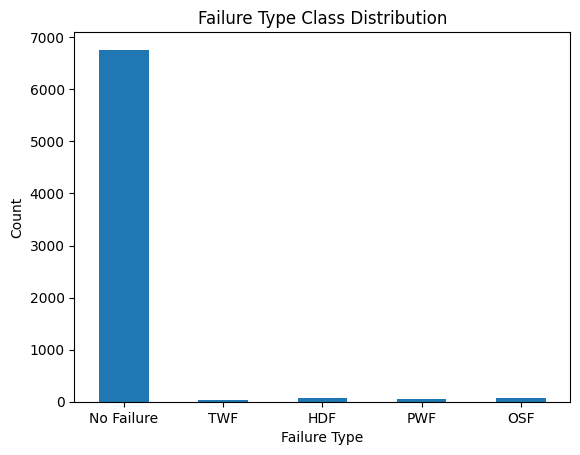

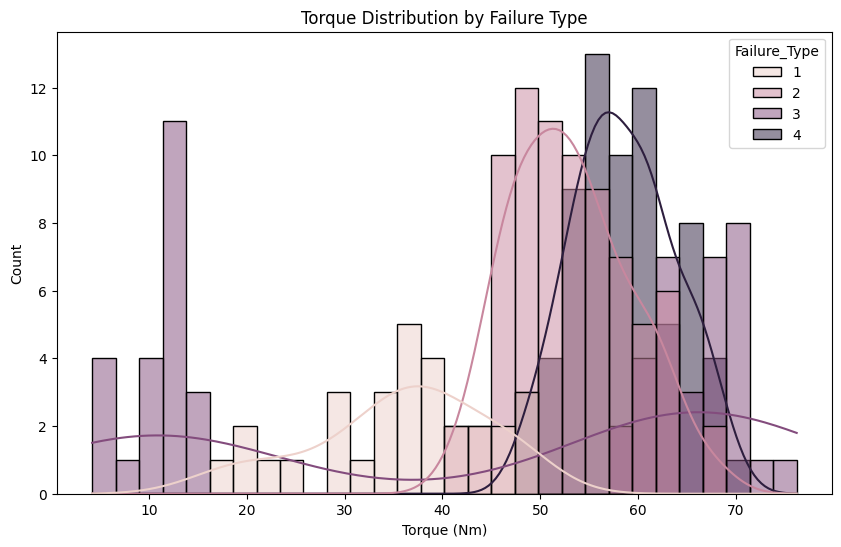

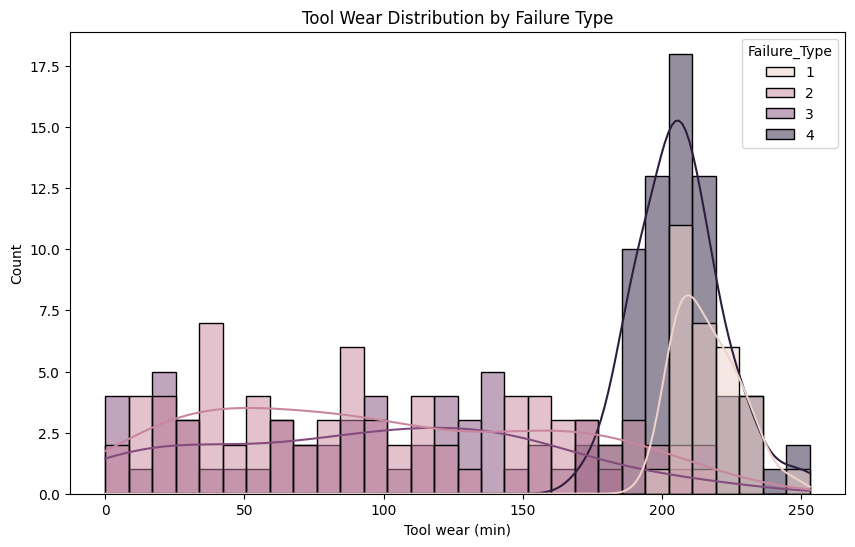

Type
L    4213
M    2074
H     706
Name: count, dtype: int64


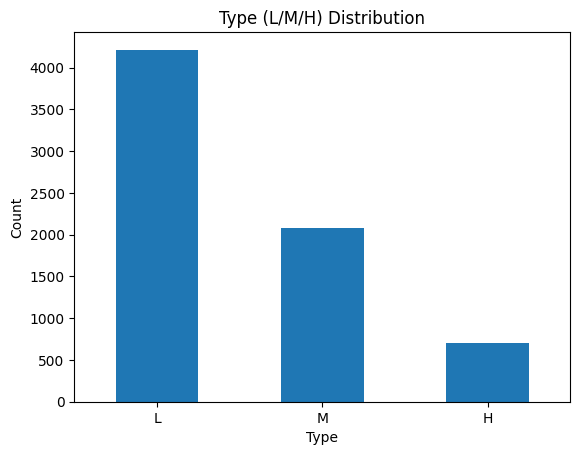

In [6]:
# TODO: Class distribution (print + bar chart)
class_distribution = train['Failure_Type'].value_counts().sort_index()
print(class_distribution)
print("\nClass distribution (%):")
print((class_distribution / len(train) * 100).round(2))

class_distribution.plot(kind='bar')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.title('Failure Type Class Distribution')
plt.xticks(
    range(len(class_distribution)),
    [CLASS_NAMES[i] for i in class_distribution.index],
    rotation=0
)
plt.show()

# TODO: Torque distribution by failure type (histogram, failures only)
failures = train[train['Failure_Type'] != 0]

plt.figure(figsize=(10, 6))
sns.histplot(
    data=failures,
    x='Torque',
    hue='Failure_Type',
    bins=30,
    kde=True,
    multiple='layer'
)
plt.xlabel('Torque (Nm)')
plt.ylabel('Count')
plt.title('Torque Distribution by Failure Type')
plt.show()

# TODO: Tool wear distribution by failure type
plt.figure(figsize=(10, 6))
sns.histplot(
    data=failures,
    x='Tool wear',
    hue='Failure_Type',
    bins=30,
    kde=True,
    multiple='layer'
)
plt.xlabel('Tool wear (min)')
plt.ylabel('Count')
plt.title('Tool Wear Distribution by Failure Type')
plt.show()

# TODO: Type distribution
print(train['Type'].value_counts())

train['Type'].value_counts().plot(kind='bar')
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Type (L/M/H) Distribution')
plt.xticks(rotation=0)
plt.show()


### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [7]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = df['Torque'] * df['Rotational speed'] * (2 * np.pi / 60)

    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']

    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
print("Train:")
print(train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean())

print("\nCurrent:")
print(current.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean())

print("\nStress:")
print(stress.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean())


Train:
                  Power_W  Temp_diff
Failure_Type                        
0             6248.240886  10.013812
1             5763.094643   9.966667
2             7403.545453   8.228947
3             6664.382233   9.823214
4             8216.074774  10.072464

Current:
                  Power_W  Temp_diff
Failure_Type                        
0             6253.901580  10.103244
1             6263.904904   9.471429
2             7112.855056   8.306250
3             7633.425249  10.283333
4             8401.126297  10.013333

Stress:
                  Power_W  Temp_diff
Failure_Type                        
0             6762.740972   9.974253
1             6213.171424   9.666667
2             8042.586225   8.211765
3             7570.226004  10.133333
4             8176.587089   9.986207


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(k_neighbors=3, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print("Post-SMOTE class distribution:")
print(y_train_smote.value_counts().sort_index())


Post-SMOTE class distribution:
Failure_Type
0    5409
1    5409
2    5409
3    5409
4    5409
Name: count, dtype: int64


*Your explanation here: why is SMOTE applied only on the training split?*

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [10]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 842.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
!pip install mlflow xgboost lightgbm imbalanced-learn

In [14]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])

for model_name, model in models_to_run.items():
    with mlflow.start_run(run_name=model_name):

        model.fit(X_train_smote, y_train_smote)

        y_pred = model.predict(X_val)

        macro_f1 = f1_score(y_val, y_pred, average='macro')
        weighted_f1 = f1_score(y_val, y_pred, average='weighted')
        accuracy = accuracy_score(y_val, y_pred)

        per_class_f1 = f1_score(
            y_val,
            y_pred,
            labels=CLASS_LIST,
            average=None
        )

        mlflow.log_param('model', model_name)
        mlflow.log_metric('macro_f1', macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('accuracy', accuracy)

        for class_id, class_f1 in zip(CLASS_LIST, per_class_f1):
            mlflow.log_metric(f'f1_class_{class_id}', class_f1)

        mlflow.sklearn.log_model(
            model,
            name='model',
            input_example=X_val.iloc[:5],
            skops_trusted_types=[
                'xgboost.core.Booster',
                'xgboost.sklearn.XGBClassifier',
                'lightgbm.basic.Booster',
                'lightgbm.sklearn.LGBMClassifier',
                'collections.OrderedDict'
            ]
        )

        results[model_name] = {
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'accuracy': accuracy,
            'f1_class_0': per_class_f1[0],
            'f1_class_1': per_class_f1[1],
            'f1_class_2': per_class_f1[2],
            'f1_class_3': per_class_f1[3],
            'f1_class_4': per_class_f1[4]
        }

# TODO: Print comparison table
comparison_df = pd.DataFrame(results).T
comparison_df.index.name = 'Model'

print("Model Comparison:")
display(comparison_df.round(4))

# TODO: Identify best model by macro F1
best_model_name = comparison_df['macro_f1'].idxmax()
best_macro_f1 = comparison_df.loc[best_model_name, 'macro_f1']

print(f"\nBest model by Macro F1: {best_model_name}")
print(f"Best Macro F1: {best_macro_f1:.4f}")


Model Comparison:


,macro_f1,weighted_f1,accuracy,f1_class_0,f1_class_1,f1_class_2,f1_class_3,f1_class_4
Model,,,,,,,,
LogisticRegression,0.5312,0.9328,0.9042,0.9483,0.1449,0.4545,0.4583,0.6500
RandomForest,0.7355,0.9855,0.9850,0.9926,0.0000,0.9286,0.9565,0.8000
XGBoost,0.7274,0.9842,0.9828,0.9915,0.0000,0.9655,0.8800,0.8000
LightGBM,0.7296,0.9851,0.9843,0.9922,0.0000,0.9655,0.8333,0.8571



Best model by Macro F1: RandomForest
Best Macro F1: 0.7355


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [16]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.4 MB/s eta 0:00:00


In [17]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_val)

    macro_f1 = f1_score(y_val, y_pred, average='macro')

    return macro_f1

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize
study.optimize(objective, n_trials=30)

print("Best Macro F1:", study.best_value)
print("Best Parameters:")
print(study.best_params)

# TODO: Train final best model
best_params = study.best_params.copy()
best_params.update({
    'random_state': 42,
    'eval_metric': 'mlogloss',
    'verbosity': 0
})

best_model = XGBClassifier(**best_params)
best_model.fit(X_train_smote, y_train_smote)

y_pred_best = best_model.predict(X_val)

best_macro_f1 = f1_score(y_val, y_pred_best, average='macro')

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
with mlflow.start_run(run_name='Optuna_Best_XGBoost'):

    mlflow.log_param('model', 'XGBoost_Optuna')
    mlflow.log_param('n_trials', 30)

    for param_name, param_value in study.best_params.items():
        mlflow.log_param(param_name, param_value)

    mlflow.log_metric('macro_f1', best_macro_f1)

    mlflow.xgboost.log_model(
        best_model,
        name='model',
        input_example=X_val.iloc[:5],
        registered_model_name='PredMaint_XGBoost'
    )

    run_id = mlflow.active_run().info.run_id

# Promote best registered model to production alias
client = mlflow.MlflowClient()

versions = client.search_model_versions(
    "name='PredMaint_XGBoost'"
)

best_version = max(
    versions,
    key=lambda v: int(v.version)
)

client.set_registered_model_alias(
    'PredMaint_XGBoost',
    'production',
    best_version.version
)

# Print improvement over baseline XGBoost
baseline_macro_f1 = results['XGBoost']['macro_f1']
improvement = best_macro_f1 - baseline_macro_f1

print(f"\nBaseline XGBoost Macro F1: {baseline_macro_f1:.4f}")
print(f"Optuna XGBoost Macro F1:   {best_macro_f1:.4f}")
print(f"Improvement:               {improvement:.4f}")

# TODO: Save with joblib.dump
joblib.dump(best_model, '/content/PredMaint_XGBoost_best.joblib')
print("\nBest XGBoost model saved successfully.")


2026/09/06 04:48:59 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_Optuna' does not exist. Creating a new experiment.


Best Macro F1: 0.7678343772046509
Best Parameters:
{'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'min_child_weight': 8.491983767203795, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.36680901970686763, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.0003671474011048667}

Baseline XGBoost Macro F1: 0.7274
Optuna XGBoost Macro F1:   0.7678
Improvement:               0.0404

Best XGBoost model saved successfully.


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [18]:
!pip install evidently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.8/581.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.3 MB/s eta 0:00:00


In [19]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary
report = Report(metrics=[
    DataDriftPreset()
])

report.run(
    reference_data=train[FEAT_COLS],
    current_data=current[FEAT_COLS]
)

report.save_html('drift_current.html')

# Print summary
result = report.as_dict()

drift_summary = result['metrics'][0]['result']

print("Drift detected:", drift_summary['dataset_drift'])
print("Number of features drifted:", drift_summary['number_of_drifted_columns'])


Drift detected: False
Number of features drifted: 0


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [21]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics
metrics = [DatasetDriftMetric()]

for feature in FEAT_COLS:
    metrics.append(ColumnDriftMetric(column_name=feature))

report = Report(metrics=metrics)

report.run(
    reference_data=train[FEAT_COLS],
    current_data=stress[FEAT_COLS]
)

# TODO: Save drift_stress.html
report.save_html('drift_stress.html')

# TODO: Print per-column drift table
report_dict = report.as_dict()

rows = []

# First metric is DatasetDriftMetric, so column metrics start from index 1
for i, feature in enumerate(FEAT_COLS, start=1):

    result = report_dict['metrics'][i]['result']

    ref_mean = train[feature].mean()
    current_mean = stress[feature].mean()
    delta = current_mean - ref_mean

    rows.append({
        'feature': feature,
        'drift detected': result.get('drift_detected'),
        'Wasserstein score': result.get('drift_score'),
        'ref mean': ref_mean,
        'current mean': current_mean,
        'delta': delta
    })

drift_table = pd.DataFrame(rows)

print(drift_table.to_string(index=False))


            feature  drift detected  Wasserstein score    ref mean  current mean      delta
    Air temperature           False           0.034355  300.011626    300.053836   0.042210
Process temperature           False           0.037740  310.004891    310.008606   0.003715
   Rotational speed            True           0.235395 1539.017589   1497.074716 -41.942873
             Torque            True           0.473946   39.995796     44.724083   4.728287
          Tool wear            True           0.645491  107.679108    148.869913  41.190806


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: Rotational speed, Torque, and Tool wear showed significant drift in the stress batch compared with the training data.
2. Most likely failure type to increase: OSF (Overstrain Failure) is the most likely failure type to increase, because the stress batch shows higher Torque and Tool wear, which are strong indicators of mechanical overstrain.
3. Retraining recommendation: The stress batch has significant drift in Rotational speed, Torque, and Tool wear, indicating that the operating conditions have changed. Since these features can strongly influence failure predictions, particularly OSF, the current model may become less accurate under stress conditions. Retraining with representative stress data would help the model adapt to the changed conditions and maintain reliable failure prediction.


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

In [23]:
import joblib

# Save the Optuna best model in the filename required by Section 4.1
joblib.dump(best_model, 'best_model.pkl')

print("Best model saved as best_model.pkl")

Best model saved as best_model.pkl


SHAP shape: (6993, 8, 5)


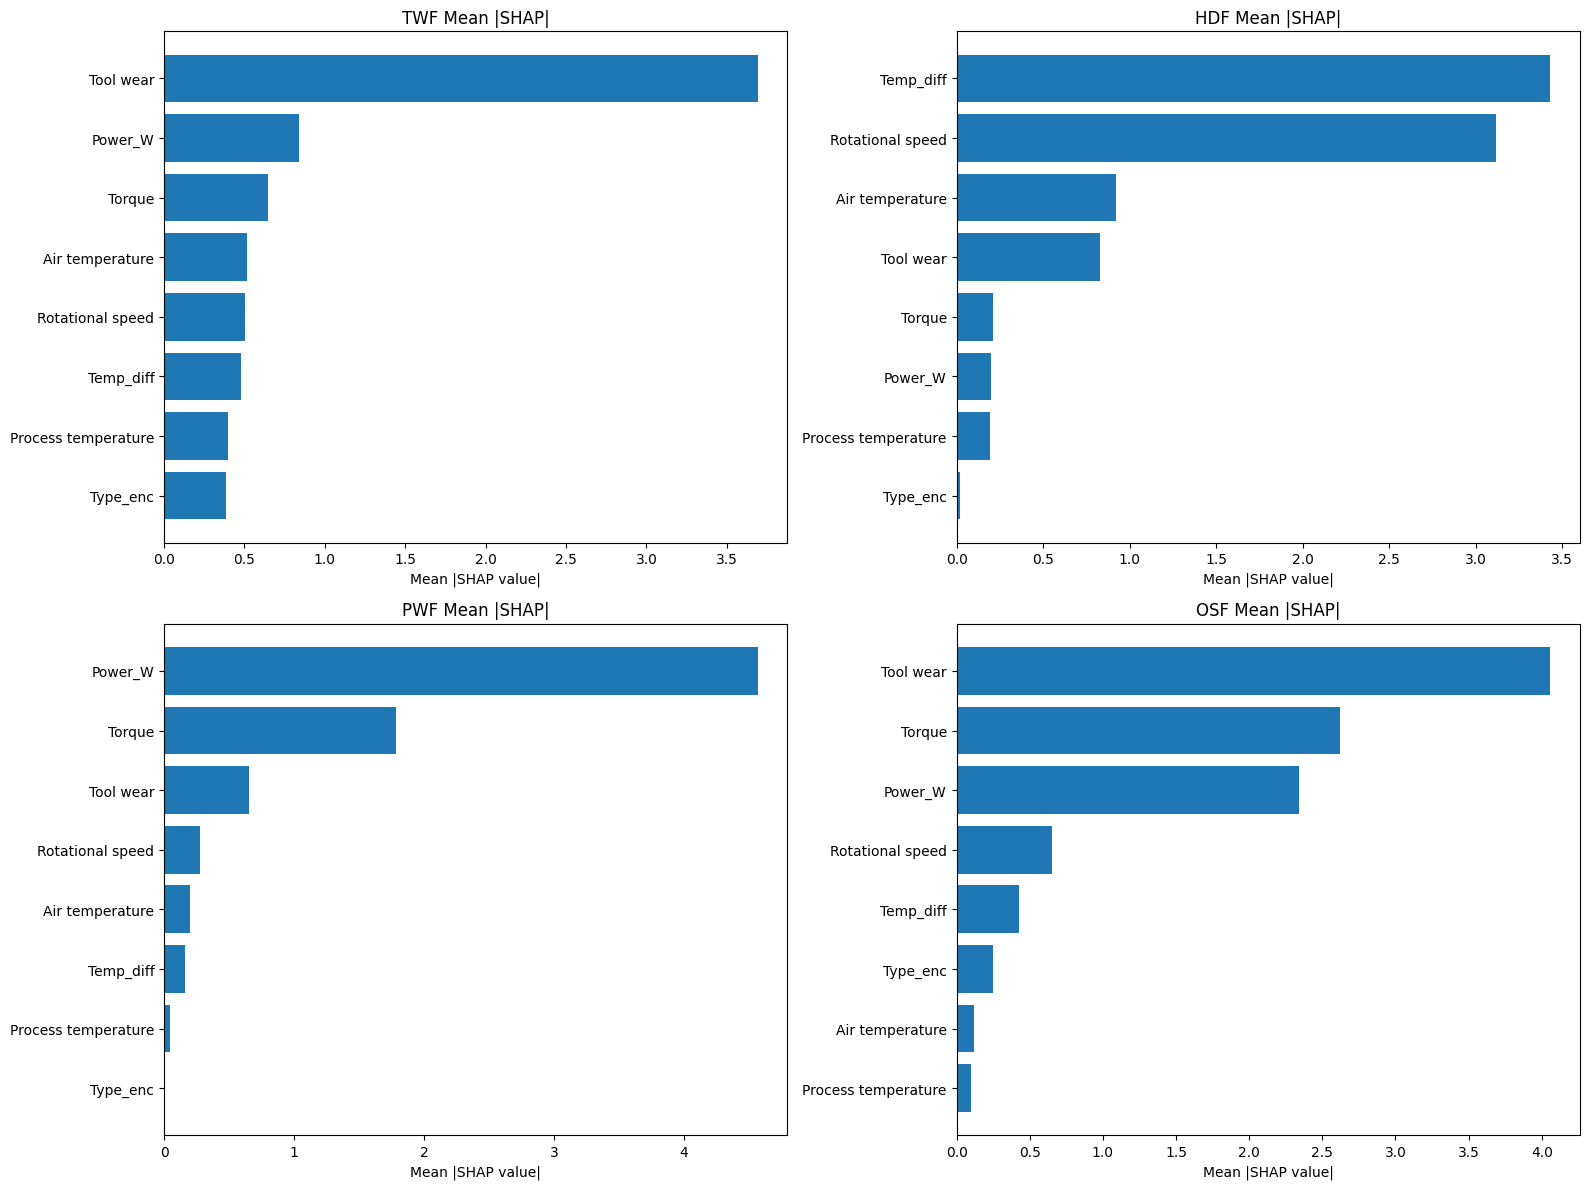


Top SHAP driver per failure class:
TWF: Tool wear (mean |SHAP| = 3.6926)
HDF: Temp_diff (mean |SHAP| = 3.4306)
PWF: Power_W (mean |SHAP| = 4.5669)
OSF: Tool wear (mean |SHAP| = 4.0585)


In [24]:
import shap
import joblib

best_model = joblib.load('best_model.pkl')

# TODO: Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(best_model)

X_shap = train[FEATURES]

shap_values = explainer.shap_values(X_shap)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_array = np.stack(shap_values, axis=-1)
else:
    shap_array = np.asarray(shap_values)

print("SHAP shape:", shap_array.shape)

# TODO: Plot 4-subplot bar chart (one per failure class)
failure_classes = {
    1: 'TWF',
    2: 'HDF',
    3: 'PWF',
    4: 'OSF'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for plot_index, (class_id, class_name) in enumerate(failure_classes.items()):

    class_shap = shap_array[:, :, class_id]

    mean_abs_shap = np.abs(class_shap).mean(axis=0)

    feature_importance = pd.Series(
        mean_abs_shap,
        index=FEATURES
    ).sort_values(ascending=True)

    axes[plot_index].barh(
        feature_importance.index,
        feature_importance.values
    )

    axes[plot_index].set_title(
        f'{class_name} Mean |SHAP|'
    )

    axes[plot_index].set_xlabel(
        'Mean |SHAP value|'
    )

plt.tight_layout()

# TODO: Save shap_per_class.png
plt.savefig('shap_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

# TODO: Print top driver per class
print("\nTop SHAP driver per failure class:")

for class_id, class_name in failure_classes.items():

    class_shap = shap_array[:, :, class_id]

    mean_abs_shap = np.abs(class_shap).mean(axis=0)

    top_feature_index = np.argmax(mean_abs_shap)

    top_feature = FEATURES[top_feature_index]
    top_value = mean_abs_shap[top_feature_index]

    print(
        f"{class_name}: {top_feature} "
        f"(mean |SHAP| = {top_value:.4f})"
    )


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: Power_W is the top SHAP driver for PWF, with a mean |SHAP| value of 4.5669. This indicates that the combined effect of Torque and Rotational speed is more influential for predicting PWF than the individual raw features.
2. Temp_diff for HDF: Temp_diff is the top SHAP driver for HDF, with a mean |SHAP| value of 3.4306. This indicates that the temperature difference between Process temperature and Air temperature is particularly important for predicting HDF.
3. Physical mechanisms: TWF and OSF are strongly associated with Tool wear, where increasing wear can degrade the tool and increase mechanical stress. HDF is associated with Temp_diff, suggesting excessive thermal difference or insufficient heat dissipation, while PWF is associated with Power_W, indicating that high combined mechanical load can increase process wear and failure risk


## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
The Optuna-tuned XGBoost model was selected as the best model because it achieved the highest Macro F1 compared with the baseline models. Macro F1 is preferred because it gives equal importance to all failure classes, including rare failures.

**2. Accuracy vs Macro F1:**
Accuracy is misleading because the dataset is highly imbalanced, with No Failure being the dominant class. A model can achieve high accuracy while missing rare but costly failures, potentially resulting in unexpected downtime, equipment damage, and higher maintenance costs.

**3. The TWF problem:**
The main limitation is data scarcity, with only 30 real TWF samples available. SMOTE and Optuna cannot fully compensate for the lack of genuine failure patterns. The next step should be to collect more real TWF examples across different machines, operating conditions, torque levels, rotational speeds, and tool-wear stages, then retrain the model.

**4. Drift and maintenance schedule:**
The stress batch showed drift in Rotational speed, Torque, and Tool wear. This indicates a change in operating conditions and increased mechanical stress, so maintenance should become more proactive, with closer monitoring and earlier preventive maintenance when these conditions persist.

**5. Actionable recommendation:**
Tool wear has increased by approximately 41.19 minutes in the stress batch → Risked failure class → TWF and OSF → Action → Closely monitor tool wear and schedule preventive tool replacement before excessive wear increases the risk of failure.